# Q7 — Does location affect data completeness?

**A composite completeness score.** Instead of one field, we score each venue with the
report's own *data-completeness* metric (`services/quality_assessment`: the mean of per-field
present-rates) applied to the four **platform-provided** facets that actually vary by
location: **a website, a cuisine tag, a Tripadvisor listing, and a TheFork listing**. Each
venue gets a score in 0–100% (0 = none of the four present, 1 = all four).

**Which facets, and why these four.** We audited every candidate signal's center-vs-periphery
gap and kept only the ones that carry a location signal: website (+12 pts), cuisine (+11), on
Tripadvisor (+10), on TheFork (+5). We deliberately drop signals that look like completeness
but are **saturated everywhere** — Google **photos** (>90% non-empty, gap −1), Google **phone**
(~84%, gap +0.4) and Google **reviews** (~94%, gap −2) — and we exclude **coordinates** because
we enriched Tripadvisor's ourselves, so they would measure our pipeline, not the platform. The
Tripadvisor *depth* fields (its own phone/email/photos) vary too, but only because they require
a Tripadvisor listing — folding them in would just re-count "on Tripadvisor".

**Scope: Milan only** — the Google seed includes surrounding municipalities (~16% of rows)
which would dominate the "periphery" bucket. Several views: the **composite completeness map**
(discrete ≈1 km cells), a **per-component grid** of the same map split by facet, a **continuous
smoothed surface**, a **distance gradient** from the Duomo, and a **center-vs-periphery
dumbbell**, plus per-quartiere and per-postcode tables.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
rows = run(queries.q7_rows())
rows["km"] = rows.apply(lambda r: distance_to_duomo_km(r["latitude"], r["longitude"]), axis=1)
rows["zone"] = rows.apply(lambda r: classify_center_periphery(r["latitude"], r["longitude"]), axis=1)
rows["neighbourhood"] = rows.apply(lambda r: assign_neighbourhood(r["latitude"], r["longitude"]), axis=1)
geo = rows.dropna(subset=["latitude", "longitude", "km"])
geo = geo[(geo["latitude"] != 0) & (geo["longitude"] != 0)].copy()
# Boolean completeness signals (platform-provided; coordinates are NOT used as a signal —
# we enriched Tripadvisor's, so they would measure our pipeline, not the platform).
geo["has_website"] = (geo["website"].str.len() > 0).astype(int)
geo["has_cuisine"] = (geo["primary_cuisine"].str.len() > 0).astype(int)
geo["has_tripadvisor"] = geo["has_tripadvisor"].astype(int)
geo["has_thefork"] = geo["has_thefork"].astype(int)
geo["ring"] = pd.cut(geo["km"], [0, 1, 2, 4, 8], labels=["0-1", "1-2", "2-4", "4-8"])

# Composite COMPLETENESS SCORE per venue — the report's "average field coverage" metric
# (services/quality_assessment: mean of per-field present-rates) applied to the four
# platform-provided facets that actually vary by location. An audit of every candidate
# signal's center-vs-periphery gap kept these four (website +12pts, cuisine +11, on
# Tripadvisor +10, on TheFork +5) and dropped the saturated ones that carry no location
# signal (Google phone +0.4, Google photos -1.0, Google reviews -1.8). 0 = none of the four
# present, 1 = all four present.
COMPLETENESS_COMPONENTS = {
    "Website": "has_website",
    "Cuisine tag": "has_cuisine",
    "On Tripadvisor": "has_tripadvisor",
    "On TheFork": "has_thefork",
}
geo["completeness"] = geo[list(COMPLETENESS_COMPONENTS.values())].mean(axis=1)

# Shared map config — centre on the Duomo, plus ~1 km grid cells (lat 0.009° / lon 0.013°
# ≈ 1 km at Milan's latitude) reused by the per-component map grid below.
Q7_CENTER = {"lat": 45.464, "lon": 9.190}
gmap = geo.assign(glat=(geo["latitude"] / 0.009).round() * 0.009,
                  glon=(geo["longitude"] / 0.013).round() * 0.013)

print(f"{len(geo)} Milan restaurants with usable coordinates "
      f"({len(rows) - len(geo)} excluded for missing coordinates); "
      f"mean completeness score = {100 * geo['completeness'].mean():.1f}%.")

8448 Milan restaurants with usable coordinates (0 excluded for missing coordinates); mean completeness score = 40.1%.


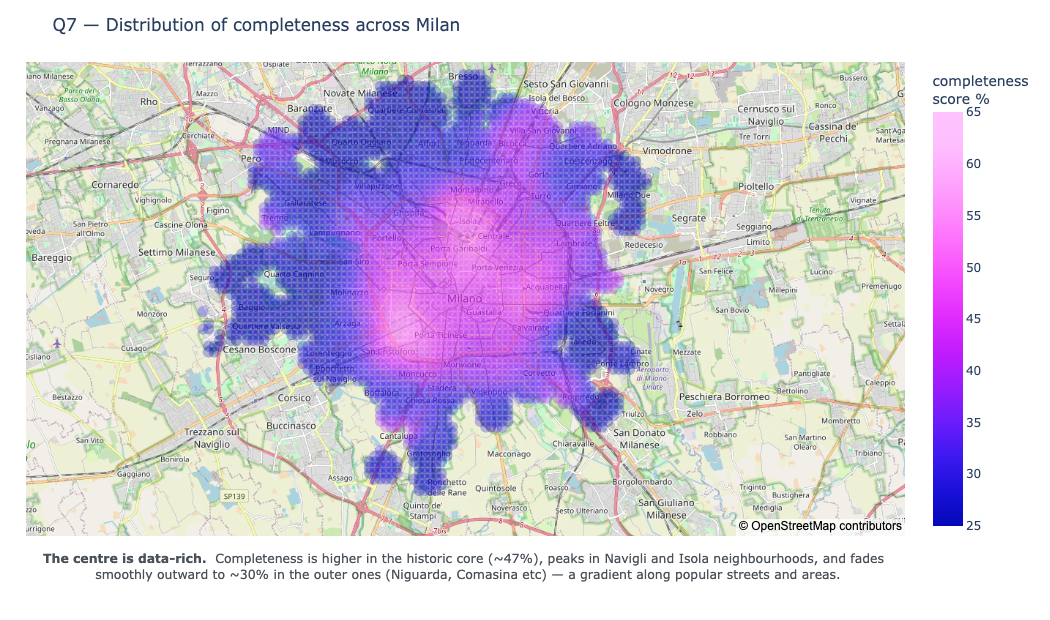

In [3]:
# Completeness MAP A — the composite score as a CONTINUOUS mask (no cells). Built PER VENUE
# (not from aggregated cells): a Nadaraya-Watson kernel estimate drops a Gaussian on every
# restaurant and reads the smoothed completeness at each grid point (smoothed score-sum /
# smoothed weight). Drawn translucent over the basemap. It is clipped to the actual Milan venue
# FOOTPRINT — rendered only where >=4 venues sit within ~550 m — so it follows the comune.
# All 8.4k venues are city='Milano'.
_lat = geo["latitude"].to_numpy(); _lon = geo["longitude"].to_numpy()
_y = geo["completeness"].to_numpy(dtype=float)
_late = np.arange(45.40, 45.55, 0.0019); _lone = np.arange(9.05, 9.31, 0.0026)
_latc = (_late[:-1] + _late[1:]) / 2; _lonc = (_lone[:-1] + _lone[1:]) / 2
_LA, _LO = np.meshgrid(_latc, _lonc, indexing="ij")
_bw_lat, _bw_lon = 0.0060, 0.0082  # smoothing bandwidth ~600 m
_r_lat, _r_lon = 0.0050, 0.0070    # ~550 m radius for the footprint (local-count) mask
_gl = _LA.ravel(); _go = _LO.ravel()
_W = np.zeros(_gl.shape); _WY = np.zeros(_gl.shape); _N = np.zeros(_gl.shape)
for _i in range(len(_lat)):
    _w = np.exp(-0.5 * (((_gl - _lat[_i]) / _bw_lat) ** 2 + ((_go - _lon[_i]) / _bw_lon) ** 2))
    _W += _w; _WY += _w * _y[_i]
    _N += (((_gl - _lat[_i]) / _r_lat) ** 2 + ((_go - _lon[_i]) / _r_lon) ** 2) <= 1.0
_rate = (100 * _WY / np.maximum(_W, 1e-9)).reshape(_LA.shape)
_m = _N.reshape(_LA.shape) >= 4  # hug the Milan venue footprint; drop empty peripheries
surf = pd.DataFrame({"lat": _LA[_m], "lon": _LO[_m], "score": _rate[_m].round(1)})
fig = px.scatter_map(surf, lat="lat", lon="lon", color="score", color_continuous_scale="Plotly3",
    range_color=[25, 65], opacity=0.28, zoom=10.55, center=Q7_CENTER,
    map_style="open-street-map", height=760, labels={"score": "completeness<br>score %"},
    title="Q7 — Distribution of completeness across Milan")
fig.update_traces(marker=dict(size=12))
# Padding (white frame) around the map + a data-driven storytelling caption underneath.
_c_core = 100 * geo.loc[geo["km"] <= 1, "completeness"].mean()
_c_edge = 100 * geo.loc[geo["km"].between(4, 8), "completeness"].mean()
fig.update_layout(paper_bgcolor="white", margin=dict(l=26, r=26, t=62, b=84))
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=-0.025, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=(f"<b>The centre is data-rich.</b>  Completeness is higher in the historic core "
          f"(~{_c_core:.0f}%), peaks in Navigli and Isola neighbourhoods, and "
          f"fades <br> smoothly outward to ~{_c_edge:.0f}% in the outer ones (Niguarda, "
          "Comasina etc) — a gradient along popular streets and areas."))
fig.show()

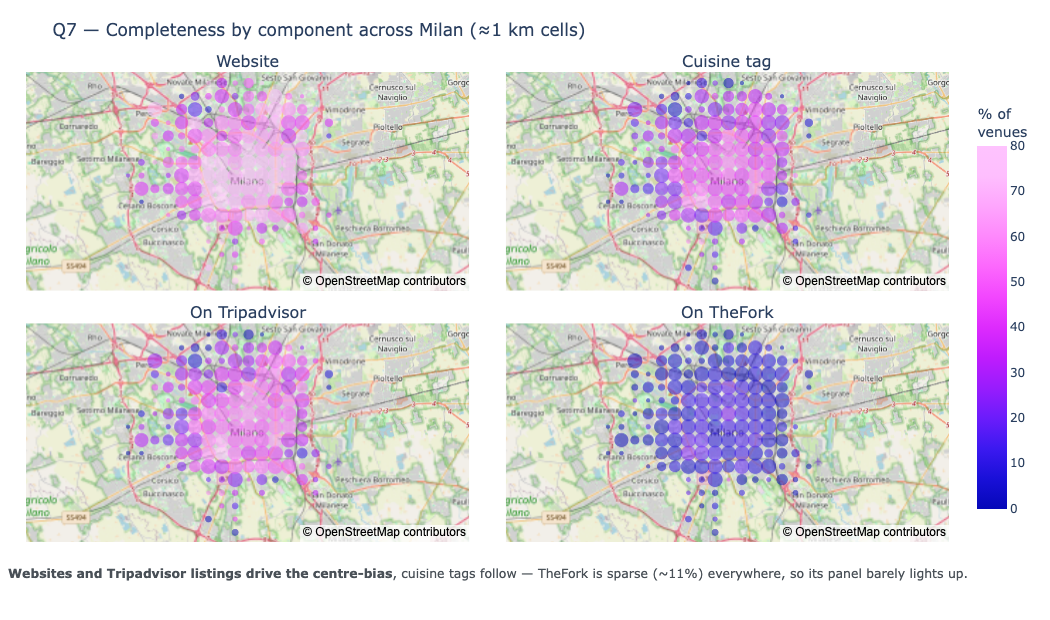

In [4]:
# Completeness MAP grid — one ~1 km cell map per component of the composite score, so you can
# see WHICH facet drives the centre-bias. Same encoding and zoom as MAP A (colour = % of venues
# carrying the facet, size = venue count). Websites, cuisine tags and Tripadvisor listings all
# fade outward; TheFork is thin (~11%) everywhere, so its panel is mostly low.
from plotly.subplots import make_subplots

_specs = [[{"type": "map"}, {"type": "map"}], [{"type": "map"}, {"type": "map"}]]
figG = make_subplots(rows=2, cols=2, specs=_specs, horizontal_spacing=0.04,
                     vertical_spacing=0.07, subplot_titles=list(COMPLETENESS_COMPONENTS))
for _i, (_lbl, _col) in enumerate(COMPLETENESS_COMPONENTS.items()):
    _cg = (gmap.groupby(["glat", "glon"], as_index=False)
           .agg(venues=(_col, "size"), rate=(_col, "mean")))
    _cg = _cg[_cg["venues"] >= 4]
    _cg["rate"] = (_cg["rate"] * 100).round(0)
    figG.add_trace(go.Scattermap(lat=_cg["glat"], lon=_cg["glon"], mode="markers",
        marker=dict(size=_cg["venues"].clip(4, 40) / 40 * 12 + 4, color=_cg["rate"],
            colorscale="Plotly3", cmin=0, cmax=80, opacity=0.52, showscale=(_i == 0),
            colorbar=dict(title="% of<br>venues", x=1.02, len=0.9)),
        showlegend=False), row=_i // 2 + 1, col=_i % 2 + 1)
_mk = dict(style="open-street-map", center=Q7_CENTER, zoom=9.5)
_tf = 100 * geo["has_thefork"].mean()
# Padding (white frame) around the grid + a data-driven storytelling caption underneath.
figG.update_layout(map=_mk, map2=_mk, map3=_mk, map4=_mk, height=940, paper_bgcolor="white",
    margin=dict(l=26, r=72, t=72, b=78),
    title="Q7 — Completeness by component across Milan (≈1 km cells)")
figG.add_annotation(xref="paper", yref="paper", x=0.5, y=-0.045, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=(f"<b>Websites and Tripadvisor listings drive the centre-bias</b>, cuisine tags follow — "
          f"TheFork is sparse (~{_tf:.0f}%) everywhere, so its panel barely lights up."))
figG.show()

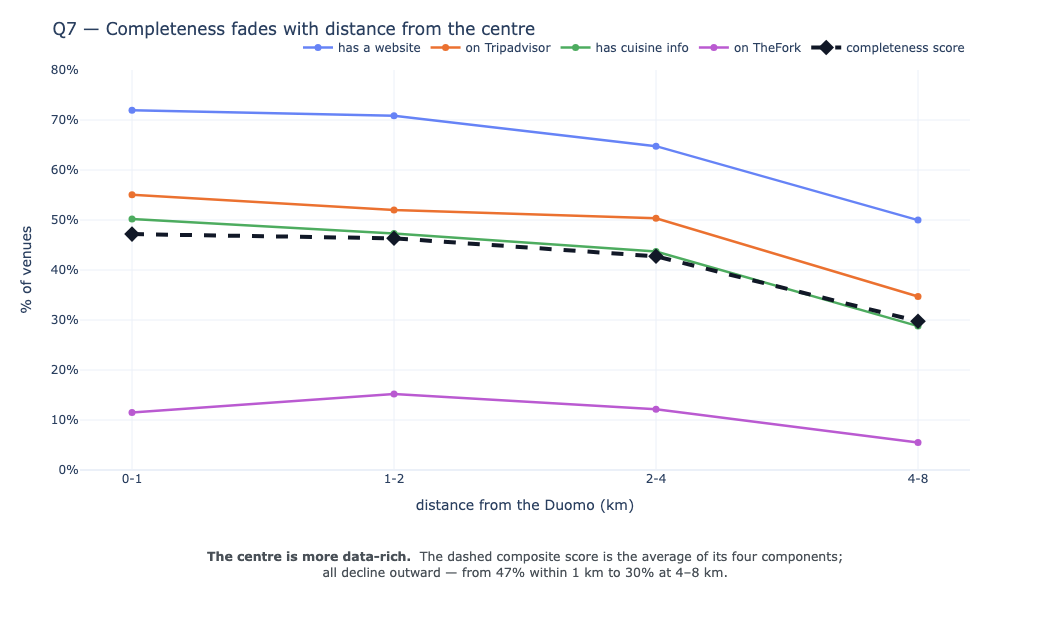

In [5]:
# Completeness fades SMOOTHLY with distance from the Duomo — a gradient, not a hard cut. The
# bold black DASHED line is the composite completeness score (the report's metric); the solid
# coloured lines are its four components. The dash keeps the composite legible where it tracks
# the cuisine line.
_g = geo.dropna(subset=["ring"]).groupby("ring", observed=True)
grad = pd.DataFrame({
    "has a website": 100 * _g["has_website"].mean(),
    "on Tripadvisor": 100 * _g["has_tripadvisor"].mean(),
    "has cuisine info": 100 * _g["has_cuisine"].mean(),
    "on TheFork": 100 * _g["has_thefork"].mean(),
})
comp = 100 * _g["completeness"].mean()
rings = list(grad.index)
_sigcol = {"has a website": "#4C6EF5", "on Tripadvisor": "#E8590C",
           "has cuisine info": "#2F9E44", "on TheFork": "#AE3EC9"}
fig = go.Figure()
for _sig, _col in _sigcol.items():
    fig.add_trace(go.Scatter(x=rings, y=grad[_sig], name=_sig, mode="lines+markers",
        line=dict(color=_col, width=2.5), marker=dict(size=7), opacity=0.85))
fig.add_trace(go.Scatter(x=rings, y=comp.values, name="completeness score", mode="lines+markers",
    line=dict(color="#111827", width=4, dash="dash"),
    marker=dict(symbol="diamond", size=12, color="#111827")))
fig.update_layout(template="plotly_white", height=670, margin=dict(b=150, t=70),
    title="Q7 — Completeness fades with distance from the centre",
    xaxis=dict(title="distance from the Duomo (km)"),
    yaxis=dict(title="% of venues", range=[0, 80], ticksuffix="%"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
# --- storytelling caption, centred UNDER the chart ---
fig.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.19, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=("<b>The centre is more data-rich.</b>  The dashed composite score is the average of its four "
          "components;<br>all decline outward — "
          f"from {comp.iloc[0]:.0f}% within 1 km to {comp.iloc[-1]:.0f}% at 4–8 km."))
fig.show()

In [6]:
def completeness_summary(df):
    return pd.Series({
        "restaurants": len(df),
        "mean_platform_count": round(df["platform_count"].mean(), 2),
        "pct_has_website": round(100 * df["has_website"].mean(), 1),
        "pct_has_cuisine": round(100 * df["has_cuisine"].mean(), 1),
        "pct_on_tripadvisor": round(100 * df["has_tripadvisor"].mean(), 1),
        "pct_on_thefork": round(100 * df["has_thefork"].mean(), 1),
        "median_google_reviews": float(df["google_review_count"].median()),
    })


q7_zone = geo.groupby("zone").apply(completeness_summary, include_groups=False).reset_index()
q7_zone = publish(q7_zone, "q7_completeness_center_periphery",
                  "Q7 — Completeness (website, cuisine, cross-listing, reviews) by center vs periphery.")
q7_zone

,zone,restaurants,mean_platform_count,pct_has_website,pct_has_cuisine,pct_on_tripadvisor,pct_on_thefork,median_google_reviews
0,center,2663.0,1.67,71.2,48.3,53.1,13.9,269.0
1,periphery,5785.0,1.53,58.8,37.1,43.3,9.3,161.0


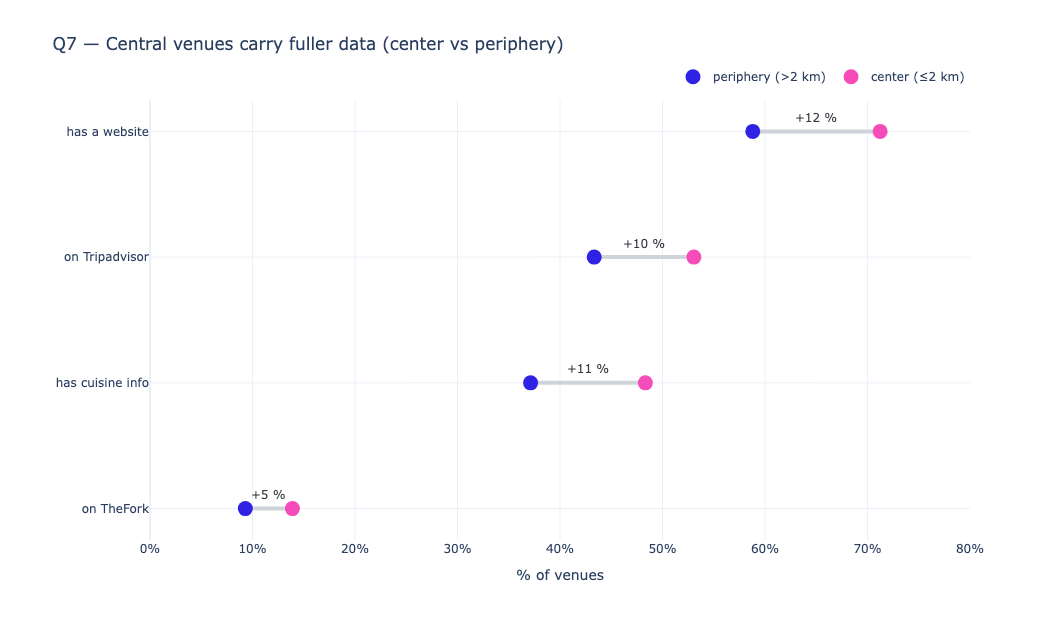

In [47]:
# Center vs periphery as a dumbbell: one row per signal, the gap shown directly. Strong
# signals only (websites, cuisine, cross-listing); photos/phones are saturated and dropped.
_sig = {"has a website": "has_website", "has cuisine info": "has_cuisine",
        "on Tripadvisor": "has_tripadvisor", "on TheFork": "has_thefork"}
_z = geo.groupby("zone")
db = pd.DataFrame({lbl: 100 * _z[col].mean() for lbl, col in _sig.items()}).T.sort_values("center")
fig = go.Figure()
for s in db.index:
    fig.add_trace(go.Scatter(x=[db.loc[s, "periphery"], db.loc[s, "center"]], y=[s, s], mode="lines",
        line=dict(color="#CED4DA", width=4), showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter(x=db["periphery"], y=db.index, mode="markers", name="periphery (>2 km)",
    marker=dict(size=15, color="#2F22E4")))
fig.add_trace(go.Scatter(x=db["center"], y=db.index, mode="markers", name="center (≤2 km)",
    marker=dict(size=15, color="#F54CBA")))
# Gap (center − periphery) labelled directly over each connector — the headline number.
for s in db.index:
    _gap = db.loc[s, "center"] - db.loc[s, "periphery"]
    _mid = (db.loc[s, "center"] + db.loc[s, "periphery"]) / 2
    fig.add_annotation(x=_mid, y=s, text=f"+{_gap:.0f} %", showarrow=False, yshift=14,
                       font=dict(size=12, color="#343A40"))
fig.update_layout(template="plotly_white", height=520, margin=dict(l=150),
    title="Q7 — Central venues carry fuller data (center vs periphery)",
    xaxis=dict(title="% of venues", ticksuffix="%", range=[0, 80]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig.show()

In [8]:
q7_hood = geo.groupby("neighbourhood").apply(completeness_summary, include_groups=False).reset_index()
q7_hood = q7_hood.sort_values("restaurants", ascending=False)
q7_hood = publish(q7_hood, "q7_completeness_neighbourhood",
                  "Q7 — Completeness by popular Milan quartiere vs other.")
q7_hood

,neighbourhood,restaurants,mean_platform_count,pct_has_website,pct_has_cuisine,pct_on_tripadvisor,pct_on_thefork,median_google_reviews
5,other,5450.0,1.53,59.3,37.0,43.0,9.5,165.0
1,duomo,983.0,1.62,70.6,45.7,51.8,9.8,215.5
7,porta_venezia,382.0,1.67,73.3,48.2,52.9,14.4,305.5
6,porta_romana,301.0,1.62,66.1,43.5,47.5,15.0,229.0
8,sempione,281.0,1.66,60.5,42.7,50.5,15.3,180.0
2,isola,278.0,1.78,77.3,54.7,59.7,18.0,312.5
3,loreto,268.0,1.53,57.1,36.6,43.7,9.3,134.0
0,brera,258.0,1.71,67.1,54.7,55.8,15.5,345.0
4,navigli,247.0,1.77,74.5,58.3,62.3,14.2,413.0


In [9]:
q7_postal = publish(run(queries.q7_postal_completeness()), "q7_completeness_by_postal_code",
                    "Q7 — Coverage and completeness by postal code (area proxy).")
q7_postal.head(15)

,postal_code,restaurants,mean_platform_count,pct_on_tripadvisor,pct_on_thefork,pct_has_website,pct_has_cuisine,median_google_reviews
0,20121,591,1.71,56.2,14.9,73.3,52.6,326.0
1,20123,573,1.64,52.7,11.0,71.9,46.1,292.0
2,20154,571,1.63,48.9,14.4,60.1,42.2,203.0
3,20124,509,1.69,52.7,16.7,69.9,49.7,317.0
4,20122,464,1.59,48.7,9.9,65.1,42.5,137.0
5,20129,392,1.66,53.6,12.8,76.3,48.2,270.0
6,20135,353,1.64,49.3,14.7,71.4,44.8,247.0
7,20159,288,1.75,58.7,16.7,68.1,53.5,278.0
8,20144,287,1.86,69.3,17.1,83.6,63.1,339.0
9,20127,248,1.52,46.8,5.2,59.7,34.7,146.0


**Answer (Q7):** Yes — **completeness falls with distance from the centre**, smoothly rather
than at a hard boundary. Scoring each venue with the report's data-completeness metric (the mean
of four platform-provided facets — website, cuisine tag, Tripadvisor listing, TheFork listing),
central venues (≤2 km from the Duomo) carry a markedly higher composite score than peripheral
ones, and the centre-bias holds for every component: website (71% vs 50%), cuisine tags (48% vs
37%), a Tripadvisor listing (53% vs 43%) and a TheFork listing, plus ~1.7× the median Google
review volume — see `q7_completeness_center_periphery`, the per-component map grid and the distance
gradient. Crucially, the signals that *don't* move are as telling as those that do: **Google
photos, phone numbers and review presence are saturated everywhere** (so they are not completeness
signals here), and **coordinates are excluded** because we enriched Tripadvisor's ourselves — they
would measure our pipeline, not the platforms.